# T1 — Different Activities: Pressure Time Series

Interactive time series showing heel and toe pressure for each foot.
Use the dropdown(s) to switch between activities.

## Study phase context

**T1** was the first exploratory phase. A single participant performed a range of activities (sitting, standing, stepping, walking, tip-toes, dancing at different BPMs) while wearing the pressure insole. The goal was to verify that the sensor could distinguish between activity types and to establish a baseline understanding of the pressure time series.

This phase informed the design of subsequent calibration and trial protocols.

In [27]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 19,
    "figure.titlesize": 25,
})
DATA_DIR = Path(".")

In [28]:
def parse_pressure_file(path):
    """Parse any semicolon-delimited pressure CSV into time_s, L_toe, L_heel, R_toe, R_heel."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    raw = path.read_bytes()
    data = raw.replace(b"\r\n", b"\n").replace(b"\r", b"\n").decode("utf-8", errors="replace")
    records = [r.strip() for r in data.split(";") if r.strip()]
    rows = []
    for rec in records:
        rec = re.sub(r"^\d+,\s*", "", rec)   # strip leading index field
        nums = re.findall(r"[\d]+\.?[\d]*", rec)
        if len(nums) < 5:
            continue
        try:
            ts = float(nums[0])
            sensors = [float(n) for n in nums[1:] if float(n) <= 1023]
            if len(sensors) < 4:
                continue
            rows.append({"ts_ms": ts, "L_toe": sensors[0], "L_heel": sensors[1],
                         "R_toe": sensors[2], "R_heel": sensors[3]})
        except ValueError:
            continue
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["time_s"] = (df["ts_ms"] - df["ts_ms"].iloc[0]) / 1000.0
    return df


def parse_imu_pressure_file(path):
    """Parse IMU-derived pressure_from_imu.csv (device_ms,toe_L,heel_L,toe_R,heel_R)."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df = df.rename(columns={"toe_L": "L_toe", "heel_L": "L_heel",
                             "toe_R": "R_toe", "heel_R": "R_heel"})
    for col in ["L_toe", "L_heel", "R_toe", "R_heel"]:
        if col not in df.columns:
            df[col] = float("nan")
    df = df.dropna(subset=["device_ms"]).reset_index(drop=True)
    df["time_s"] = (df["device_ms"] - df["device_ms"].iloc[0]) / 1000.0
    return df

In [29]:
def plot_pressure(df, title=""):
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
    TOE_COLOR  = "#2ecc71"
    HEEL_COLOR = "#e74c3c"
    for ax, (foot, toe_col, heel_col) in zip(axes, [
        ("Left",  "L_toe", "L_heel"),
        ("Right", "R_toe", "R_heel"),
    ]):
        if df is None or df.empty or toe_col not in df.columns:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center",
                    transform=ax.transAxes, fontsize=20, color="gray")
            ax.set_title(f"{foot} foot")
            continue
        ax.plot(df["time_s"], df[toe_col],  color=TOE_COLOR,  lw=1.5,
                label=f"{foot} toe",  alpha=0.85)
        ax.plot(df["time_s"], df[heel_col], color=HEEL_COLOR, lw=1.5,
                label=f"{foot} heel", alpha=0.85)
        ax.set_ylabel("Pressure (ADC)")
        ax.set_title(f"{foot} foot")
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
        ax.grid(linestyle="--", alpha=0.35)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Participant / data discovery

In [30]:
FILES = sorted([f for f in DATA_DIR.glob("*.csv") if not f.name.startswith("_")])
# Friendly display names: "1_sitting.csv" -> "1 Sitting"
def friendly(path):
    stem = path.stem.replace("_", " ")
    return stem.title()

activity_map = {friendly(f): f for f in FILES}
activities = list(activity_map.keys())
print(f"Found {len(activities)} activity files:")
for a in activities:
    print(f"  {a}")

Found 12 activity files:
  10 Heels 90 Bpm
  11 100 Bpm
  12 130 Bpm
  1 Sitting
  2 Air
  3 Standing Soft
  4 Standing Hard
  5 Stepping In Place Hard 90Bpm
  6 Stepping In Place Soft 90 Bpm
  7 Walking Hard 90 Bpm
  8 Walking Soft 90 Bpm
  9 Tip Toes 90 Bpm


## Interactive time series

In [31]:
def load_data_t1(activity, _=None):
    path = activity_map.get(activity)
    if path is None:
        return pd.DataFrame()
    return parse_pressure_file(path)

selector = widgets.Dropdown(
    options=activities, value=activities[0] if activities else None,
    description="Activity:",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="340px"),
)
out = widgets.Output()

def on_change(change):
    out.clear_output(wait=True)
    with out:
        df = load_data_t1(selector.value)
        plot_pressure(df, title=f"T1 — {selector.value}")

selector.observe(on_change, names="value")
display(widgets.HBox([selector]), out)
with out:
    df = load_data_t1(selector.value)
    plot_pressure(df, title=f"T1 — {selector.value}")

Output()

## Pressure variation across hard-floor walking speeds

Figure saved to: /Users/zoe/Library/CloudStorage/OneDrive-Personal/University/year4/Masters/Final Submission Data analysis/t1_different_activities/boxplot_walking_speeds_hard.png


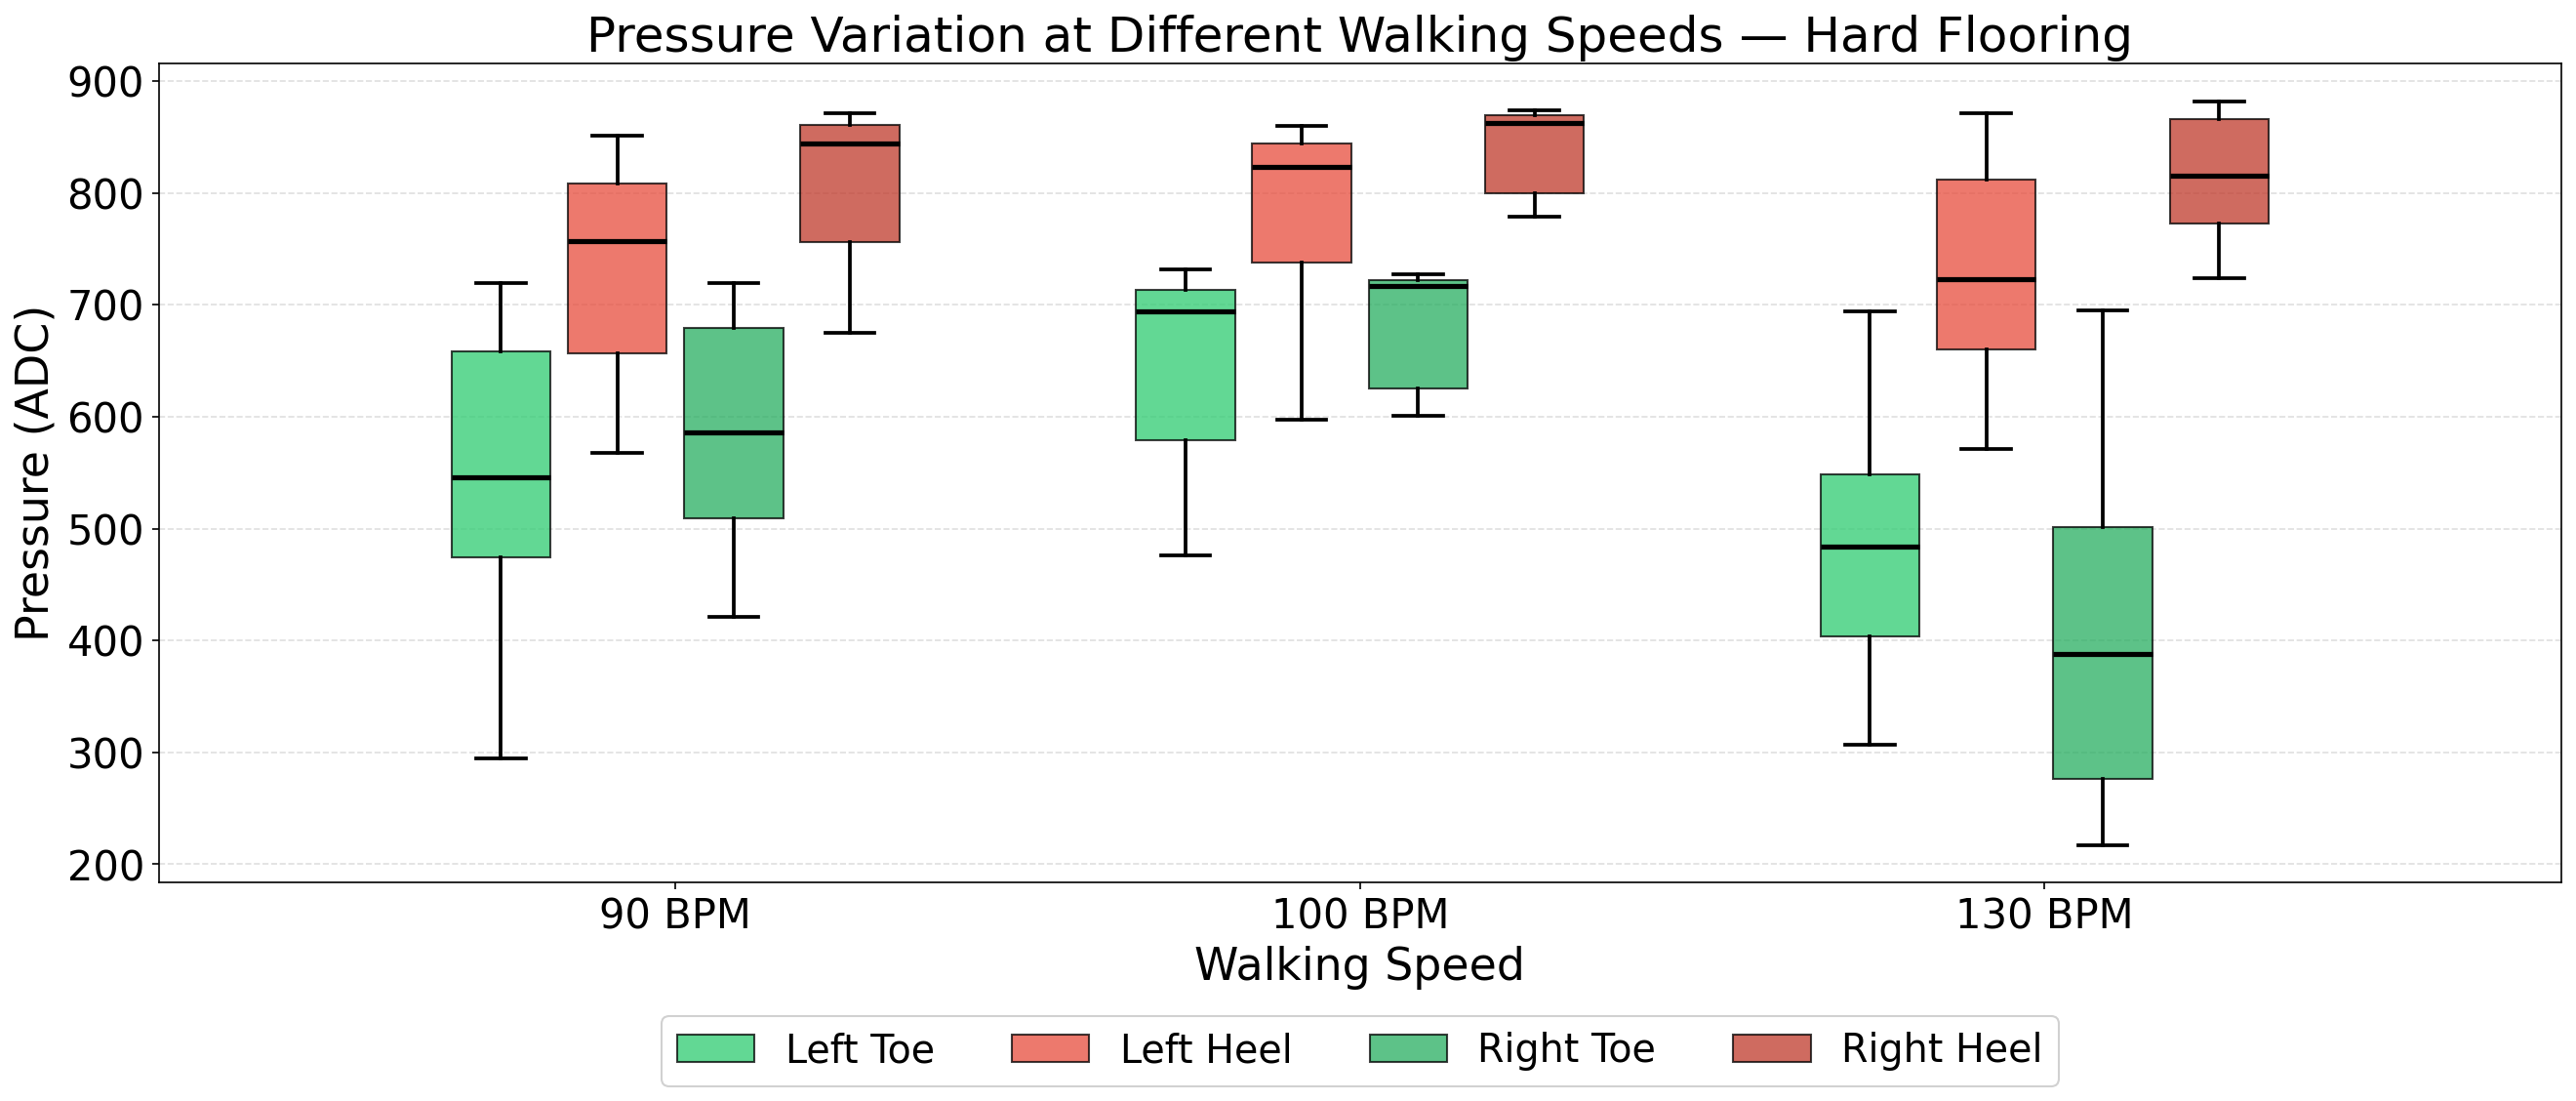

In [32]:
HARD_WALK_FILES = {
    "90 BPM": DATA_DIR / "7_walking_hard_90_BPM.csv",
    "100 BPM": DATA_DIR / "11_100_BPM.csv",
    "130 BPM": DATA_DIR / "12_130_BPM.csv",
}

SENSORS       = ["L_toe",     "L_heel",     "R_toe",      "R_heel"]
SENSOR_LABELS = ["Left Toe", "Left Heel", "Right Toe", "Right Heel"]
BOX_COLORS    = ["#2ecc71",   "#e74c3c",    "#27ae60",    "#c0392b"]

# ── Export settings ────────────────────────────────────────────────────────────
EXPORT_PATH = DATA_DIR / "boxplot_walking_speeds_hard.png"   # change extension to .pdf or .svg if preferred
EXPORT_DPI  = 300                                             # 300 dpi is standard for print/reports
# ──────────────────────────────────────────────────────────────────────────────

data_by_speed = {label: parse_pressure_file(path) for label, path in HARD_WALK_FILES.items()}
speeds = list(data_by_speed.keys())

fig, ax = plt.subplots(figsize=(18, 8))

n_speeds  = len(speeds)
n_sensors = len(SENSORS)
width     = 0.17
base_pos  = np.arange(n_speeds)
offsets   = np.linspace(-(n_sensors - 1) / 2 * width,
                         (n_sensors - 1) / 2 * width, n_sensors)

legend_handles = []
for i, (sensor, s_label, color) in enumerate(zip(SENSORS, SENSOR_LABELS, BOX_COLORS)):
    plot_data = [data_by_speed[s][sensor].dropna().values
                 for s in speeds if sensor in data_by_speed[s].columns]
    pos = base_pos + offsets[i]
    bp  = ax.boxplot(
        plot_data,
        positions=pos,
        widths=width * 0.85,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.75),
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(linewidth=1.8),
        capprops=dict(linewidth=1.8),
        flierprops=dict(marker="o", markersize=3, alpha=0.35, markeredgewidth=0),
    )
    legend_handles.append(bp["boxes"][0])

ax.set_xticks(base_pos)
ax.set_xticklabels(speeds)
ax.set_xlabel("Walking Speed")
ax.set_ylabel("Pressure (ADC)")
ax.set_title("Pressure Variation at Different Walking Speeds — Hard Flooring")
ax.legend(legend_handles, SENSOR_LABELS,
          loc="upper center", bbox_to_anchor=(0.5, -0.14),
          ncol=4, framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
fig.savefig(EXPORT_PATH, dpi=EXPORT_DPI, bbox_inches="tight")
print(f"Figure saved to: {EXPORT_PATH.resolve()}")
plt.show()